# Classification – Blood Group Detection (Multi-Feature Source)

Notebook này mở rộng từ notebook 03 gốc để hỗ trợ ba nguồn feature:

| Notebook nguồn | File CSV | Phương pháp |
|---|---|---|
| 02 | `processed/color_segmentation/color_segmentation_features.csv` | Color, LBP, GLCM, Gradient, Contour |
| 04 | `processed/frequency_domain/frequency_domain_features.csv` | FFT Ring Spectrum, DoG Wavelet |
| 05 | `processed/morphological_spatial/morphological_spatial_features.csv` | Morphological Profile, Hu Moments, Spatial |

**Chế độ feature** (chọn bằng `FEATURE_MODE`):
- `"color"` : chỉ dùng notebook 02
- `"frequency"` : chỉ dùng notebook 04
- `"morphological"` : chỉ dùng notebook 05
- `"color+frequency"` : merge 02 + 04
- `"color+morphological"` : merge 02 + 05
- `"all"` : merge cả ba

Mục tiêu: train nhiều mô hình, so sánh theo `f1_macro`, lưu model tốt nhất.


## 0. Config

In [37]:
from pathlib import Path
from datetime import datetime
import json

import joblib, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from google.colab import drive
drive.mount('/content/drive')

# (Lưu ý: Thay thư mục này cho đúng với dự án của bạn trên Drive)
ROOT_DRIVE = Path('/content/drive/MyDrive/Blood Group Detection.coco')
MODEL_DIR = ROOT_DRIVE / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Đã cấu hình thư mục lưu model tại: {MODEL_DIR}")

# ── Paths to feature CSVs ─────────────────────────────────────────────────────
FEATURE_PATHS = {
    "color":         ROOT_DRIVE / "processed" / "color_segmentation"   / "color_segmentation_features.csv",
    "frequency":     ROOT_DRIVE / "processed" / "frequency_domain"     / "frequency_domain_features.csv",
    "morphological": ROOT_DRIVE / "processed" / "morphological_spatial"/ "morphological_spatial_features.csv",
}

# ── Main settings ─────────────────────────────────────────────────────────────
#  Options: "color", "frequency", "morphological",
#           "color+frequency", "color+morphological", "all"
FEATURE_MODE      = "all"

TARGET            = "blood_group"   # "blood_group" | "abo" | "rh"
USE_ORIGINAL_SPLIT= False
TEST_SIZE         = 0.20
RANDOM_STATE      = 42

ROOT = ROOT_DRIVE
MODEL_DIR

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã cấu hình thư mục lưu model tại: /content/drive/MyDrive/Blood Group Detection.coco/models


PosixPath('/content/drive/MyDrive/Blood Group Detection.coco/models')

## 1. Load & Merge Feature CSVs

In [38]:
import pandas as pd
from pathlib import Path

META_COLS = ["split", "file_name", "blood_group", "abo", "rh"]

# 1. Đưa FEATURE_PATHS ra ngoài hàm để dễ quản lý
FEATURE_PATHS = {
    # LƯU Ý: Nhớ thay "..." bằng tên file CSV chính xác của bạn nhé!
    "color": Path("/content/drive/MyDrive/Blood Group Detection.coco/processed/color_segmentation/color_segmentation_features.csv"),
    "frequency": Path("/content/drive/MyDrive/Blood Group Detection.coco/processed/frequency_domain/frequency_domain_features.csv"), 
    "morphological": Path("/content/drive/MyDrive/Blood Group Detection.coco/processed/morphological_spatial/morphological_spatial_features.csv")
}

def load_csv(key):
    # 2. Dòng bị thiếu: Lấy đường dẫn tương ứng với key và gán vào biến path
    path = FEATURE_PATHS[key]
    
    if not path.exists():
        # Tách dictionary map các notebook ra để code clean hơn
        notebook_map = {
            'color': '02',
            'frequency': '04',
            'morphological': '05'
        }
        # Lấy tên notebook tương ứng với key, nếu không có thì để trống
        nb_name = notebook_map.get(key, 'unknown')
        
        raise FileNotFoundError(f"Feature CSV not found: {path}\nRun notebook {nb_name} first.")
        
    df = pd.read_csv(path)
    print(f"  [{key}] {df.shape}")
    return df

def merge_feature_sources(mode: str) -> pd.DataFrame:
    """Load và merge các CSV theo mode. Join trên file_name."""
    keys = {
        "color":              ["color"],
        "frequency":          ["frequency"],
        "morphological":      ["morphological"],
        "color+frequency":    ["color", "frequency"],
        "color+morphological":["color", "morphological"],
        "all":                ["color", "frequency", "morphological"],
    }[mode]

    dfs = {}
    for k in keys:
        dfs[k] = load_csv(k)

    if len(dfs) == 1:
        return list(dfs.values())[0]

    # Merge on file_name; keep META_COLS from first df, suffix duplicates
    base_key = keys[0]
    merged   = dfs[base_key].copy()
    for k in keys[1:]:
        other = dfs[k]
        # Drop duplicate META_COLS from other (keep base)
        other_feat = other.drop(columns=[c for c in META_COLS if c in other.columns], errors="ignore")
        # Remove columns already in merged to avoid _x/_y suffix clutter
        other_feat = other_feat[[c for c in other_feat.columns if c not in merged.columns]]
        merged = pd.concat([merged, other_feat], axis=1)
    return merged

# Chạy thử (Giả sử biến FEATURE_MODE đã được khai báo trước đó là "color")
print(f"Feature mode: {FEATURE_MODE}")
df = merge_feature_sources(FEATURE_MODE)
print(f"Merged shape: {df.shape}")
print(f"NaN total: {int(df.isna().sum().sum())}")
df.head()

Feature mode: all
  [color] (2072, 387)
  [frequency] (2072, 217)
  [morphological] (2072, 287)
Merged shape: (2072, 867)
NaN total: 0


,split,file_name,blood_group,abo,rh,resized_width,resized_height,anti_a_blue_mask_present,anti_a_blue_area_ratio,anti_a_blue_component_count,...,reaction_candidate_angular_bin2,reaction_candidate_angular_bin3,reaction_candidate_angular_bin4,reaction_candidate_angular_bin5,reaction_candidate_angular_bin6,reaction_candidate_angular_bin7,reaction_candidate_angular_entropy,reaction_candidate_bbox_aspect_ratio,reaction_candidate_bbox_fill_ratio,reaction_candidate_bbox_area_norm
0,train,B- (8)_jpg.rf.Y4gSPakmKnxXtqrN20gd.jpg,B-,B,-,1200,393,0,0.000000,0,...,0.069215,0.190217,0.278083,0.014005,0.020826,0.179117,2.557031,0.299385,0.391770,0.823577
1,train,AB- (59)_jpg.rf.XqNFkV6f7JNjc2LlN7za.jpg,AB-,AB,-,991,302,1,0.108122,1,...,0.066105,0.143734,0.234657,0.034606,0.026094,0.207171,2.613588,0.317895,0.508132,0.958628
2,train,A+ (7)_jpg.rf.YMFIioqVqZGqD5EMeCtF.jpg,A+,A,+,1200,365,1,0.058824,3,...,0.055696,0.250407,0.163505,0.056550,0.078969,0.190307,2.742546,0.305439,0.416411,0.995833
3,train,A+ (14)_jpg.rf.sSksp3LBJpQi1ohZIjYl.jpg,A+,A,+,1199,363,1,0.011015,2,...,0.006129,0.224701,0.163713,0.027111,0.109200,0.184659,2.592141,0.324578,0.297715,0.847437
4,train,B- (95)_jpg.rf.Y9dEJiYDftKo36eOzT7I.jpg,B-,B,-,1019,341,0,0.000000,0,...,0.066455,0.196855,0.220717,0.040602,0.046944,0.198013,2.697223,0.346897,0.630722,0.964671


## 2. Prepare Features

In [39]:
numeric_cols  = df.select_dtypes(include="number").columns.tolist()
feature_cols  = [c for c in numeric_cols if c not in META_COLS]

X = df[feature_cols]
y = df[TARGET].astype(str)

print(f"Target:        {TARGET}")
print(f"Feature count: {len(feature_cols)}")
print(f"Classes:       {sorted(y.unique())}")
print("\nTarget distribution:")
print(y.value_counts())

Target:        blood_group
Feature count: 862
Classes:       ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']

Target distribution:
blood_group
A+     300
O+     299
B+     299
B-     298
A-     296
AB+    292
AB-    285
O-       3
Name: count, dtype: int64


## 3. Train/Test Split

In [40]:
if USE_ORIGINAL_SPLIT:
    train_mask = df["split"] == "train"
    test_mask  = df["split"].isin(["valid", "test"])
    X_train, X_test = X.loc[train_mask], X.loc[test_mask]
    y_train, y_test = y.loc[train_mask], y.loc[test_mask]
    print("Using original split.")
else:
    min_count = y.value_counts().min()
    if min_count < 2:
        raise ValueError("Stratified split requires at least 2 samples per class.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
    print("Using stratified split.")

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print("\nTrain distribution:"); print(y_train.value_counts())
print("\nTest distribution:");  print(y_test.value_counts())

Using stratified split.
X_train: (1657, 862)  X_test: (415, 862)

Train distribution:
blood_group
A+     240
B+     239
O+     239
B-     238
A-     237
AB+    234
AB-    228
O-       2
Name: count, dtype: int64

Test distribution:
blood_group
O+     60
A+     60
B+     60
B-     60
A-     59
AB+    58
AB-    57
O-      1
Name: count, dtype: int64


## 4. Define Candidate Models

Notebook này bổ sung **Gradient Boosting** so với notebook 03 gốc, phù hợp hơn khi feature space lớn từ ba nguồn.

| Model | Ghi chú |
|---|---|
| Logistic Regression | Baseline tuyến tính |
| Linear SVM | Tuyến tính mạnh khi nhiều feature |
| RBF SVM | Phi tuyến, kernel Gaussian |
| KNN | Khoảng cách trong feature space |
| Random Forest | Ensemble cây bất biến với scale |
| Extra Trees | Ngẫu nhiên hơn RF, thường nhanh hơn |
| Gradient Boosting | Boosting từng bước, thường mạnh nhất trên tabular |


In [41]:
def scaled_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler",  StandardScaler()),
        ("model",   model),
    ])

def tree_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("model",   model),
    ])

models = {
    "logistic_regression": scaled_pipeline(
        LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
    "linear_svm": scaled_pipeline(
        LinearSVC(class_weight="balanced", max_iter=10000, random_state=RANDOM_STATE)),
    "rbf_svm": scaled_pipeline(
        SVC(kernel="rbf", C=10.0, gamma="scale", class_weight="balanced", random_state=RANDOM_STATE)),
    "knn": scaled_pipeline(
        KNeighborsClassifier(n_neighbors=5)),
    "random_forest": tree_pipeline(
        RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)),
    "extra_trees": tree_pipeline(
        ExtraTreesClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)),
    "gradient_boosting": tree_pipeline(
        GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4,
                                   subsample=0.8, random_state=RANDOM_STATE)),
}

print("Models:", list(models.keys()))

Models: ['logistic_regression', 'linear_svm', 'rbf_svm', 'knn', 'random_forest', 'extra_trees', 'gradient_boosting']


## 5. Cross-Validation & Test Evaluation

In [42]:
min_train_count = y_train.value_counts().min()
n_splits = max(2, min(3, int(min_train_count)))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

rows, fitted_models = [], {}
for name, pipe in models.items():
    print(f"Training {name}...", end=" ", flush=True)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows.append({
        "model":              name,
        "feature_mode":       FEATURE_MODE,
        "n_features":         len(feature_cols),
        "cv_f1_macro_mean":   cv_scores.mean(),
        "cv_f1_macro_std":    cv_scores.std(),
        "test_accuracy":      accuracy_score(y_test, pred),
        "test_f1_macro":      f1_score(y_test, pred, average="macro"),
        "test_f1_weighted":   f1_score(y_test, pred, average="weighted"),
    })
    fitted_models[name] = pipe
    print(f"cv={cv_scores.mean():.3f}±{cv_scores.std():.3f}  "
          f"test_f1_macro={rows[-1]['test_f1_macro']:.3f}")

results_df = pd.DataFrame(rows).sort_values("test_f1_macro", ascending=False).reset_index(drop=True)
results_df

Training logistic_regression... cv=0.781±0.008  test_f1_macro=0.824
Training linear_svm... cv=0.756±0.003  test_f1_macro=0.796
Training rbf_svm... cv=0.797±0.006  test_f1_macro=0.834
Training knn... cv=0.711±0.003  test_f1_macro=0.766
Training random_forest... cv=0.788±0.007  test_f1_macro=0.809
Training extra_trees... cv=0.787±0.004  test_f1_macro=0.826
Training gradient_boosting... cv=0.796±0.003  test_f1_macro=0.838


,model,feature_mode,n_features,cv_f1_macro_mean,cv_f1_macro_std,test_accuracy,test_f1_macro,test_f1_weighted
0,gradient_boosting,all,862,0.796420,0.003420,0.956627,0.838305,0.955432
1,rbf_svm,all,862,0.797243,0.006376,0.951807,0.834243,0.950914
2,extra_trees,all,862,0.787020,0.004242,0.942169,0.825741,0.941173
3,logistic_regression,all,862,0.781170,0.008408,0.939759,0.823574,0.938672
4,random_forest,all,862,0.788286,0.007423,0.922892,0.808784,0.921550
5,linear_svm,all,862,0.755991,0.002943,0.908434,0.796073,0.906982
6,knn,all,862,0.711113,0.002949,0.874699,0.766125,0.873167


## 6. Best Model – Classification Report & Confusion Matrix

In [43]:
best_name  = results_df.loc[0, "model"]
best_model = fitted_models[best_name]
best_pred  = best_model.predict(X_test)

print(f"Best model: {best_name}  (feature_mode={FEATURE_MODE})")
print(classification_report(y_test, best_pred, digits=4))

Best model: gradient_boosting  (feature_mode=all)
              precision    recall  f1-score   support

          A+     0.9500    0.9500    0.9500        60
          A-     0.9180    0.9492    0.9333        59
         AB+     0.9661    0.9828    0.9744        58
         AB-     1.0000    1.0000    1.0000        57
          B+     0.9643    0.9000    0.9310        60
          B-     0.9828    0.9500    0.9661        60
          O+     0.9219    0.9833    0.9516        60
          O-     0.0000    0.0000    0.0000         1

    accuracy                         0.9566       415
   macro avg     0.8379    0.8394    0.8383       415
weighted avg     0.9550    0.9566    0.9554       415



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


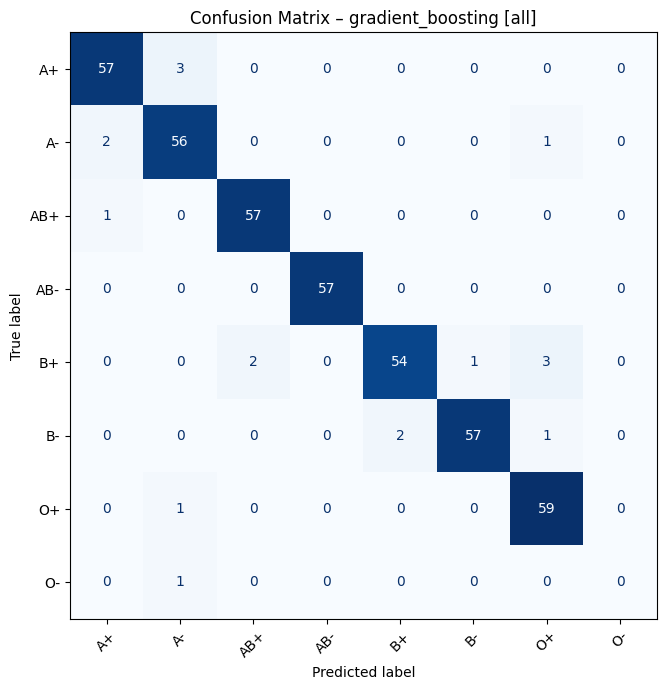

In [44]:
labels = sorted(y.unique())
cm     = confusion_matrix(y_test, best_pred, labels=labels)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
ax.set_title(f"Confusion Matrix – {best_name} [{FEATURE_MODE}]")
plt.tight_layout()
plt.show()

## 7. Feature Importance (Tree-Based Models)

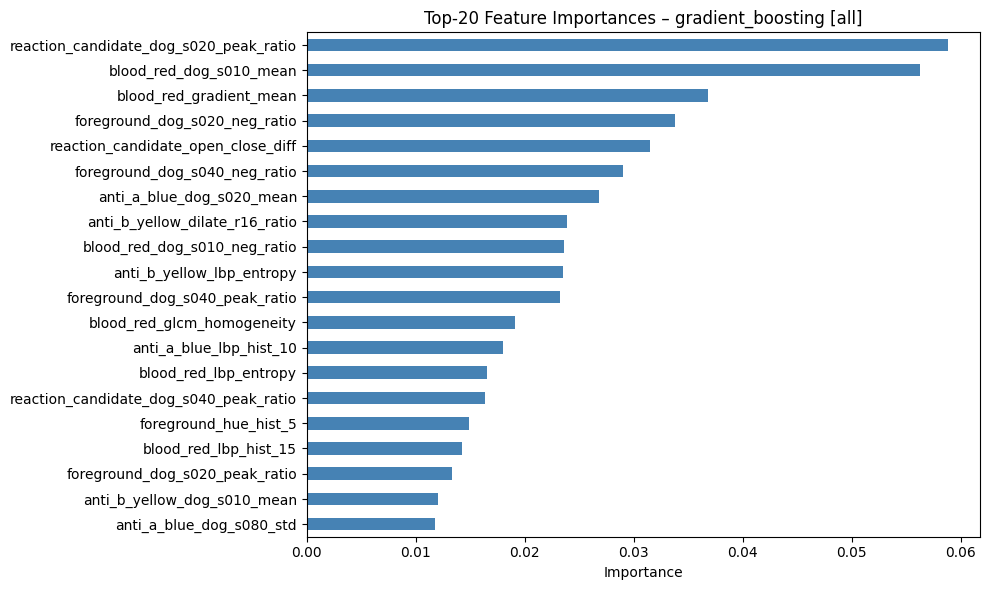


Top 20 features:
reaction_candidate_dog_s020_peak_ratio    0.05882
blood_red_dog_s010_mean                   0.05629
blood_red_gradient_mean                   0.03682
foreground_dog_s020_neg_ratio             0.03378
reaction_candidate_open_close_diff        0.03144
foreground_dog_s040_neg_ratio             0.02897
anti_a_blue_dog_s020_mean                 0.02676
anti_b_yellow_dilate_r16_ratio            0.02388
blood_red_dog_s010_neg_ratio              0.02361
anti_b_yellow_lbp_entropy                 0.02354
foreground_dog_s040_peak_ratio            0.02325
blood_red_glcm_homogeneity                0.01910
anti_a_blue_lbp_hist_10                   0.01798
blood_red_lbp_entropy                     0.01654
reaction_candidate_dog_s040_peak_ratio    0.01639
foreground_hue_hist_5                     0.01483
blood_red_lbp_hist_15                     0.01427
foreground_dog_s020_peak_ratio            0.01333
anti_b_yellow_dog_s010_mean               0.01205
anti_a_blue_dog_s080_std        

In [45]:
if hasattr(best_model["model"], "feature_importances_"):
    imp = pd.Series(best_model["model"].feature_importances_, index=feature_cols)
    top20 = imp.nlargest(20)
    fig, ax = plt.subplots(figsize=(10, 6))
    top20.sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Top-20 Feature Importances – {best_name} [{FEATURE_MODE}]")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()
    print("\nTop 20 features:")
    print(top20.round(5))
else:
    print(f"{best_name} does not support feature_importances_.")

## 8. Feature Mode Comparison (Optional)

  [color] (2072, 387)
[color] n_feat=382  f1_macro=0.804
  [frequency] (2072, 217)
[frequency] n_feat=212  f1_macro=0.796
  [morphological] (2072, 287)
[morphological] n_feat=282  f1_macro=0.743
  [color] (2072, 387)
  [frequency] (2072, 217)
[color+frequency] n_feat=587  f1_macro=0.813
  [color] (2072, 387)
  [morphological] (2072, 287)
[color+morphological] n_feat=657  f1_macro=0.802
  [color] (2072, 387)
  [frequency] (2072, 217)
  [morphological] (2072, 287)
[all] n_feat=862  f1_macro=0.824


,feature_mode,n_features,test_f1_macro,test_accuracy
5,all,862,0.823609,0.939759
3,color+frequency,587,0.813362,0.927711
0,color,382,0.804122,0.918072
4,color+morphological,657,0.801894,0.915663
1,frequency,212,0.796288,0.908434
2,morphological,282,0.742605,0.848193


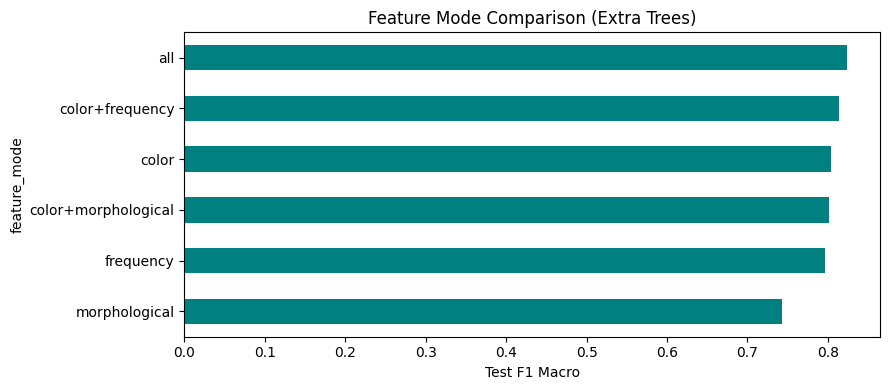

In [49]:
# Chạy cell này để so sánh các feature mode khác nhau mà không cần restart.
# Có thể mất vài phút nếu dataset lớn.

RUN_COMPARISON = True   # Đổi thành True để chạy

if RUN_COMPARISON:
    all_modes = ["color", "frequency", "morphological", "color+frequency", "color+morphological", "all"]
    compare_rows = []
    for mode in all_modes:
        try:
            df_m = merge_feature_sources(mode)
            num  = df_m.select_dtypes(include="number").columns
            fc   = [c for c in num if c not in META_COLS]
            X_m  = df_m[fc]; y_m = df_m[TARGET].astype(str)
            Xtr, Xte, ytr, yte = train_test_split(
                X_m, y_m, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_m)
            pipe = tree_pipeline(
                ExtraTreesClassifier(n_estimators=200, class_weight="balanced",
                                     n_jobs=-1, random_state=RANDOM_STATE))
            pipe.fit(Xtr, ytr)
            pred = pipe.predict(Xte)
            compare_rows.append({
                "feature_mode": mode,
                "n_features": len(fc),
                "test_f1_macro": f1_score(yte, pred, average="macro"),
                "test_accuracy": accuracy_score(yte, pred),
            })
            print(f"[{mode}] n_feat={len(fc)}  f1_macro={compare_rows[-1]['test_f1_macro']:.3f}")
        except Exception as e:
            print(f"[{mode}] SKIP: {e}")

    compare_df = pd.DataFrame(compare_rows).sort_values("test_f1_macro", ascending=False)
    display(compare_df)

    fig, ax = plt.subplots(figsize=(9, 4))
    compare_df.sort_values("test_f1_macro").plot(
        x="feature_mode", y="test_f1_macro", kind="barh", ax=ax, color="teal", legend=False)
    ax.set_xlabel("Test F1 Macro"); ax.set_title("Feature Mode Comparison (Extra Trees)")
    plt.tight_layout(); plt.show()
else:
    print("Set RUN_COMPARISON = True to run cross-mode comparison.")

## 9. Save Best Model

In [47]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
safe_mode = FEATURE_MODE.replace("+", "_")

joblib_path = MODEL_DIR / f"{safe_mode}_{TARGET}_{best_name}_{timestamp}.joblib"
pkl_path    = MODEL_DIR / f"{safe_mode}_{TARGET}_{best_name}_{timestamp}.pkl"
metrics_path= MODEL_DIR / f"{safe_mode}_{TARGET}_metrics_{timestamp}.csv"
report_path = MODEL_DIR / f"{safe_mode}_{TARGET}_classification_report_{timestamp}.txt"

model_package = {
    "model":              best_model,
    "model_name":         best_name,
    "feature_mode":       FEATURE_MODE,
    "target":             TARGET,
    "feature_columns":    feature_cols,
    "classes":            labels,
    "use_original_split": USE_ORIGINAL_SPLIT,
    "test_size":          TEST_SIZE,
    "random_state":       RANDOM_STATE,
    "saved_at":           timestamp,
    "metrics":            results_df.to_dict(orient="records"),
}

joblib.dump(model_package, joblib_path, compress=3)
with open(pkl_path, "wb") as f:
    pickle.dump(model_package, f)

results_df.to_csv(metrics_path, index=False)
with report_path.open("w", encoding="utf-8") as f:
    f.write(f"Best model: {best_name}\n")
    f.write(f"Feature mode: {FEATURE_MODE}\n")
    f.write(f"Target: {TARGET}\n")
    f.write(f"Saved at: {timestamp}\n\n")
    f.write(classification_report(y_test, best_pred, digits=4))

print(f"Saved model: {joblib_path}")
print(f"Saved pkl:   {pkl_path}")
print(f"Metrics:     {metrics_path}")
print(f"Report:      {report_path}")

Saved model: /content/drive/MyDrive/Blood Group Detection.coco/models/all_blood_group_gradient_boosting_20260620_113152.joblib
Saved pkl:   /content/drive/MyDrive/Blood Group Detection.coco/models/all_blood_group_gradient_boosting_20260620_113152.pkl
Metrics:     /content/drive/MyDrive/Blood Group Detection.coco/models/all_blood_group_metrics_20260620_113152.csv
Report:      /content/drive/MyDrive/Blood Group Detection.coco/models/all_blood_group_classification_report_20260620_113152.txt


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 10. Verify: Load & Predict

In [48]:
loaded   = joblib.load(joblib_path)
loaded_m = loaded["model"]
loaded_f = loaded["feature_columns"]

sample    = df.sample(10, random_state=RANDOM_STATE)
# Chỉ dùng các cột feature_columns; reindex để đảm bảo thứ tự
sample_X  = sample[loaded_f] if all(c in sample.columns for c in loaded_f) else \
            pd.DataFrame(sample).reindex(columns=loaded_f, fill_value=0.0)
sample_pred = loaded_m.predict(sample_X)

pd.DataFrame({
    "file_name":  sample["file_name"].values,
    "true_label": sample[TARGET].values,
    "pred_label": sample_pred,
})

,file_name,true_label,pred_label
0,B+ (58)_jpg.rf.I3orMQDrL1FRmrVNSw1s.jpg,B+,B+
1,B- (96)_jpg.rf.1tvOcBmVMchFdTSOpvtX.jpg,B-,B-
2,B- (123)_jpg.rf.gbt9xfXECQH0Vm0eaxQm.jpg,B-,B-
3,B+ (114)_jpg.rf.PdepoPOh8YbZJ8ZWorlJ.jpg,B+,B+
4,B- (50)_jpg.rf.cMKqC9dGna7ovPdlnTGK.jpg,B-,B-
5,A+ (100)_jpg.rf.f4M0SfLjI5o8Rq8UkAvX.jpg,A+,A+
6,B+ (54)_jpg.rf.yCzUowNbL8ECNb5DYlCv.jpg,B+,B+
7,B- (116)_jpg.rf.UalXNlK7fRUxt1tGNp2J.jpg,B-,B-
8,B- (72)_jpg.rf.Juhy0TtV5e4SVstElFUK.jpg,B-,B-
9,A- (78)_jpg.rf.3Bd3tbW8fmgmY3sOWcor.jpg,A-,A-


## 11. Ghi chú

**Điểm mới so với notebook 03 gốc:**
- Hỗ trợ 3 nguồn feature và 6 chế độ merge.
- Bổ sung model **Gradient Boosting** (thường mạnh nhất trên tabular data khi feature nhiều).
- Lưu thêm thông tin `feature_mode` vào model package và tên file.
- Cell so sánh feature mode (Section 8) có thể chạy độc lập mà không cần restart.
- Model package ghi `feature_columns` đầy đủ, đảm bảo inference app dùng đúng bộ feature.

**Gợi ý cho báo cáo:**
- Chạy `FEATURE_MODE = "all"` và `RUN_COMPARISON = True` để có bảng so sánh đầy đủ.
- So sánh macro F1 theo feature mode → thấy được bộ feature nào đóng góp nhiều nhất.
- Feature importance (Section 7) cho biết feature nào từ notebook 04/05 được Extra Trees xem trọng.
